### Cargar librerias

In [51]:
import sys  # Acceder a funciones y configuraciones del sistema
from pathlib import Path  # Manejo de rutas de archivos

import pandas as pd  # Manejo y analisis de datos
import matplotlib.pyplot as plt  # Creacion de graficos basicos
import seaborn as sns  # Creacion de graficos estadisticos
from scipy import stats  # Aplicar pruebas y metodos estadisticos
from scipy.stats import fisher_exact  # Evaluar relacion entre variables categoricas
from scipy.stats import mannwhitneyu  # Comparar dos grupos sin asumir normalidad
from statsmodels.stats.outliers_influence import variance_inflation_factor  # Evaluar multicolinealidad
from statsmodels.api import add_constant  # Agregar una constante para calcular el VIF

sns.set_style("whitegrid")  # Definir el estilo de los graficos
pd.set_option("display.max_columns", None)  # Mostrar todas las columnas del DataFrame


#Encontrar la raiz del proyecto
ROOT = Path.cwd()
while not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)) # Encuentra la carpeta src
from src.function_clean import load_data


In [18]:
#Ruta de la base de datos
ruta = "../database/silver/clean_data/clean_data_customers.csv"

In [19]:
df = load_data(ruta) # Cargando los datos
df.head(5) # revision de los 5 valores

,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,customer_id_anonymous
0,2023-01-15,2025-12-05,450.5,12.0,0.0,C00000
1,2023-02-20,2025-05-10,1200.0,45.0,0.0,C00001
2,2023-04-12,2025-06-01,890.2,22.0,0.0,C00002
3,2023-05-30,2024-12-20,310.0,5.0,1.0,C00003
4,2023-06-21,2025-04-15,2500.0,NaN,0.0,C00004


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   signup_date            109 non-null    str    
 1   last_purchase_date     106 non-null    str    
 2   monthly_spend          88 non-null     float64
 3   total_shipments        107 non-null    float64
 4   churn_label            109 non-null    float64
 5   customer_id_anonymous  109 non-null    str    
dtypes: float64(3), str(3)
memory usage: 5.2 KB


## Analisis univariado

In [21]:
#Distribucion de churn_label despues de limpieza
df["churn_label"].value_counts(dropna=False,normalize=True).round(4)*100

churn_label
0.0    75.23
1.0    24.77
Name: proportion, dtype: float64

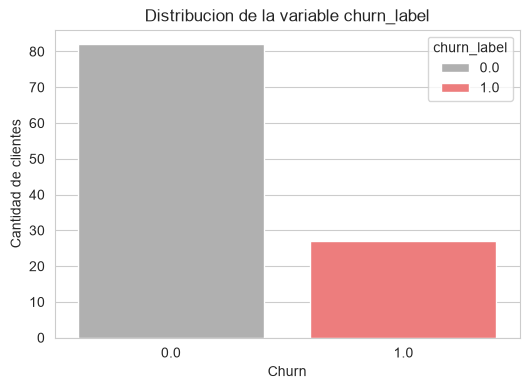

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df[df["churn_label"].notna()],x="churn_label", palette=["#B0B0B0", "#FF6B6B"],hue="churn_label")
plt.title("Distribucion de la variable churn_label")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()

Se identifica que se presenta u desvalanceo moderado, es decir no es tan extremo, sin embargo, es importante tenerlo presente mas adelante por ejemplo, el accuracy va a ser una metrica engañosa (un modelo que rediga "no churn" siempre acertaria el 75% de las veces sin aprender nada util). Conviene priorizar recall, precision, F1 o AUC-ROC para el segmento que cancela.

Adicionalmente podemos decir que Aproximadamente 1 de cada 4 clientes (24.8%) de la base cancelo el servicio, mientras que el 75.2% restante se mantiene activo.

### Descripción de las variables numericas

In [23]:
df[["monthly_spend", "total_shipments"]].describe()

,monthly_spend,total_shipments
count,88.000000,107.000000
mean,1654.675568,51.401869
std,2199.485175,79.861184
min,10.000000,0.000000
25%,417.500000,10.000000
50%,850.000000,22.000000
75%,1850.000000,50.000000
max,10000.000000,500.000000


La variable monthly_spend presenta un gasto mensual promedio de 1.654,68 y una mediana de 850. La diferencia entre ambas medidas puede estar influenciada por los valores atipicos identificados durante la exploracion de los datos. Ademas, la desviacion estandar de 2.199,49 evidencia una alta variabilidad en el gasto mensual de los clientes.

La variable total_shipments registra un promedio de 51,4 envios y una mediana de 22. Tambien presenta una alta variabilidad, con una desviacion estandar de 79,86 y un valor maximo de 500 envios

### Distribucion de las variables numericas

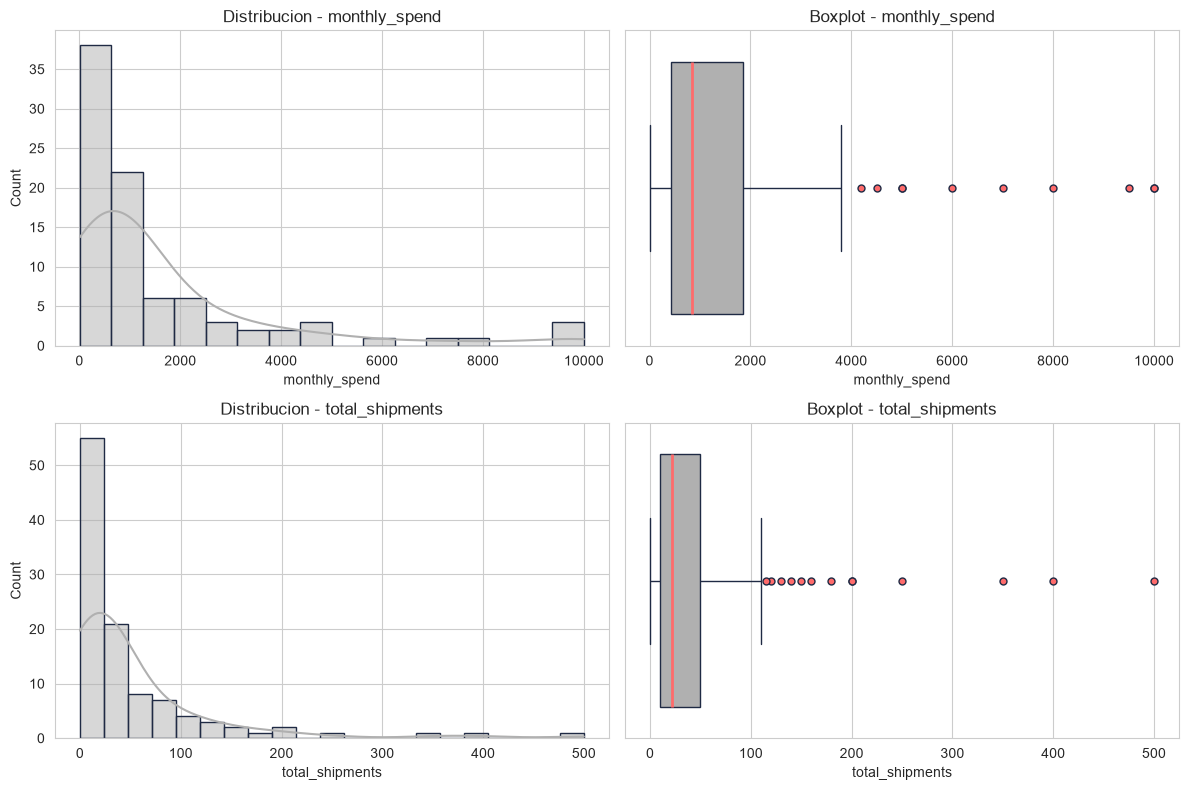

In [24]:
fig, axes = plt.subplots(2,2,figsize=(12, 8))

sns.histplot(df["monthly_spend"].dropna(),kde=True,ax=axes[0, 0],color="#B0B0B0",edgecolor="#1F2A44")
axes[0,0].set_title("Distribucion - monthly_spend")
sns.boxplot(x=df["monthly_spend"].dropna(),ax=axes[0, 1],color= "#B0B0B0", boxprops={"edgecolor": "#1F2A44"},
        whiskerprops={"color": "#1F2A44"},
        capprops={"color": "#1F2A44"},
        medianprops={"color": "#FF6B6B", "linewidth": 2},
        flierprops={
            "marker": "o",
            "markerfacecolor": "#FF6B6B",
            "markeredgecolor": "#1F2A44",
            "markersize": 5
        })
axes[0,1].set_title("Boxplot - monthly_spend")
sns.histplot(df["total_shipments"].dropna(), kde=True, ax=axes[1, 0],color="#B0B0B0",edgecolor="#1F2A44")
axes[1, 0].set_title("Distribucion - total_shipments")
sns.boxplot(x=df["total_shipments"].dropna(), ax=axes[1, 1],color= "#B0B0B0", boxprops={"edgecolor": "#1F2A44"},
        whiskerprops={"color":"#1F2A44"},
        capprops={"color":"#1F2A44"},
        medianprops={"color": "#FF6B6B", "linewidth": 2},
        flierprops={
            "marker":"o",
            "markerfacecolor": "#FF6B6B",
            "markeredgecolor": "#1F2A44",
            "markersize":5
        })
axes[1,1].set_title("Boxplot - total_shipments")
plt.tight_layout()
plt.show()

### Prueba de normalidad

In [25]:
for col in ["monthly_spend", "total_shipments"]:
    stat, p = stats.shapiro(df[col].dropna())
    print(f"{col}: Shapiro-Wilk p-value = {p:.4f} -> "
          f"{'Normal' if p > 0.05 else 'No normal'}")

monthly_spend: Shapiro-Wilk p-value = 0.0000 -> No normal
total_shipments: Shapiro-Wilk p-value = 0.0000 -> No normal


Tanto monthly_spend como total_shipments tiene una distribucion sesgada hacia la derecha y se observa que la mayoria de los clientes se concentran en valores bajos, muy pocos gastan o envian mas que el resto el test de normalidad indica que ninguna de las dos variable sigue una distribucion normal (p < 0.05 en ambos casos).

Al observar la distrubucion y aplicar la prueba de normalidad, se puede decir que para el tratamiento de los valores nulos de ambas variables se pueden imputar con metodos como la mediana porque es mas apropiada que la media ya que la media se ve distorsionada por los valores altos de la cola, mientras que la mediana refleja mejor el comportamiento tipico del cliente.

### Outliers y su relación con churn_label

In [26]:
# Validar la proporcion de valores atipicos de la cola derecha por churn_label
for col in ["monthly_spend", "total_shipments"]:
    q3 = df[col].quantile(0.75)
    iqr = df[col].quantile(0.75) - df[col].quantile(0.25)
    umbral = q3 + 1.5 * iqr
    outliers = df[df[col] >umbral]
    print(f"{col}: {len(outliers)} outliers detectados")
    print(outliers["churn_label"].value_counts(normalize=True).round(3)*100)

monthly_spend: 10 outliers detectados
churn_label
0.0    100.0
Name: proportion, dtype: float64
total_shipments: 13 outliers detectados
churn_label
0.0    100.0
Name: proportion, dtype: float64


Se observa que el 100% de los outliers detectados en monthly_spend (10 clientes) y en monthly_spend (13 clientes) corresponden a clientes que no cancelaron el servicio. Ningun cliente con churn aparece en estos grupos.

Por lo tanto, se puede inferir que el hecho de que se concentren exclusivamente en clientes activos sugiere que son datos reales de un segmento distinto: clientes de alto valor (posiblemente mayoristas o compradores muy frecuentes). si fueran valores mal cargados o fallas del sistema, se esperaria verlos distribuidos al azar entre ambos grupos. Por otra parte se concidera no imputar estos valores antes de modelar. ya que hacerlo borraria la señal que distingue a los clientes de mayor valor. Si conviene aplicar una transformacion (log) si el modelo lo requiere por sensibilidad a la escala, pero manteniendo la informacion completa.

### Tendencias

In [27]:
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")
df["last_purchase_date"] = pd.to_datetime(df["last_purchase_date"], errors="coerce")
df.head()

,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,customer_id_anonymous
0,2023-01-15,2025-12-05,450.5,12.0,0.0,C00000
1,2023-02-20,2025-05-10,1200.0,45.0,0.0,C00001
2,2023-04-12,2025-06-01,890.2,22.0,0.0,C00002
3,2023-05-30,2024-12-20,310.0,5.0,1.0,C00003
4,2023-06-21,2025-04-15,2500.0,NaN,0.0,C00004


In [28]:
#Verificar clientes registrados por mes
df["mes_registro"] = df["signup_date"].dt.to_period("M").astype(str)
registros_mes = (df.groupby("mes_registro").size().reset_index(name="clientes_registrados"))


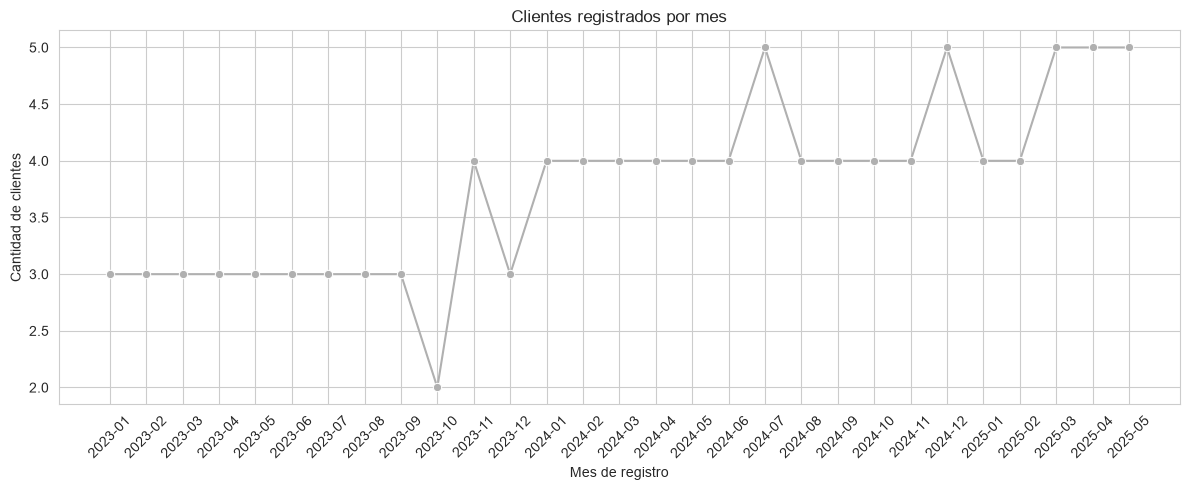

In [29]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=registros_mes,x="mes_registro",y="clientes_registrados",marker="o",color="#B0B0B0")
plt.title("Clientes registrados por mes")
plt.xlabel("Mes de registro")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se observa una tendencia moderadamente creciente en la cantidad de clientes registrados. En 2023 se registraron principalmente tres clientes por mes, mientras que en 2024 la cifra aumento a cuatro y alcanzo cinco clientes en algunos periodos de 2024 y 2025. Esto sugiere una mejora moderada en la captacion de clientes

In [30]:
# porcentaje de participacion de clientes churn por mes de registro
churn_mes_registro = (df.groupby("mes_registro")["churn_label"].agg(clientes="count", tasa_churn="mean").reset_index())
churn_mes_registro["tasa_churn"] = (churn_mes_registro["tasa_churn"] * 100)
churn_mes_registro.head()

,mes_registro,clientes,tasa_churn
0,2023-01,3,66.666667
1,2023-02,3,33.333333
2,2023-03,3,33.333333
3,2023-04,3,0.000000
4,2023-05,3,66.666667


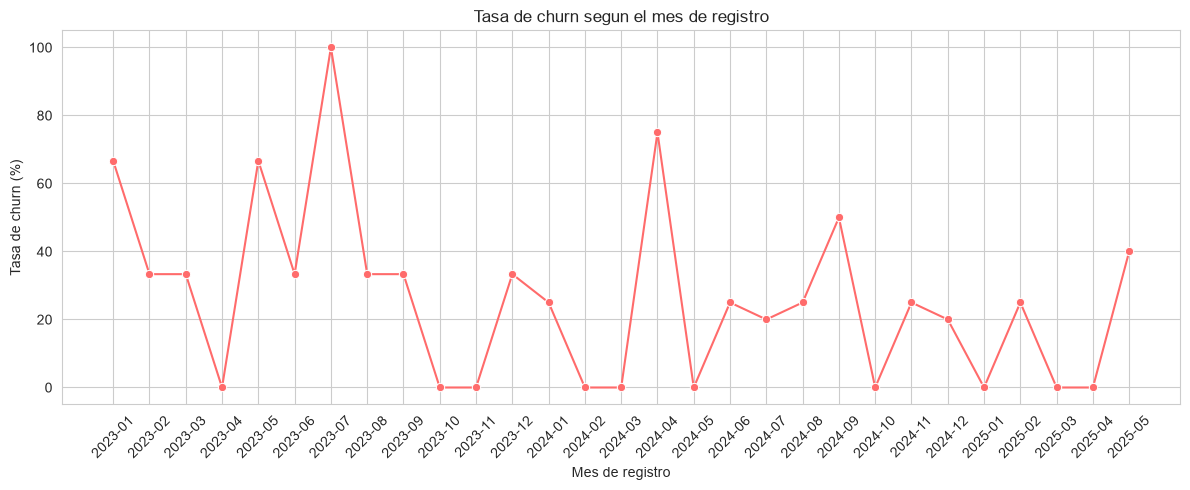

In [31]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=churn_mes_registro,x="mes_registro",y="tasa_churn",marker="o",color="#FF6B6B")
plt.title("Tasa de churn segun el mes de registro")
plt.xlabel("Mes de registro")
plt.ylabel("Tasa de churn (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se puede observar que la tasa de churn presenta variaciones importantes entre los meses de registro, alcanzando sus valores mas altos en julio de 2023 y abril de 2024, sin embargo, teniendo en cuenta que son muy pocos registros por mes, seria conveniente agruparlo por trimestre

In [32]:
# porcentaje de participacion de clientes churn por trimestre de registro
df["trimestre_registro"] = (df["signup_date"].dt.to_period("Q").astype(str))
churn_trimestre = (df.groupby("trimestre_registro")["churn_label"].agg(clientes="count", tasa_churn="mean").reset_index())
churn_trimestre["tasa_churn"] = (churn_trimestre["tasa_churn"] * 100)
churn_trimestre.head(5)

,trimestre_registro,clientes,tasa_churn
0,2023Q1,9,44.444444
1,2023Q2,9,33.333333
2,2023Q3,9,55.555556
3,2023Q4,9,11.111111
4,2024Q1,12,8.333333


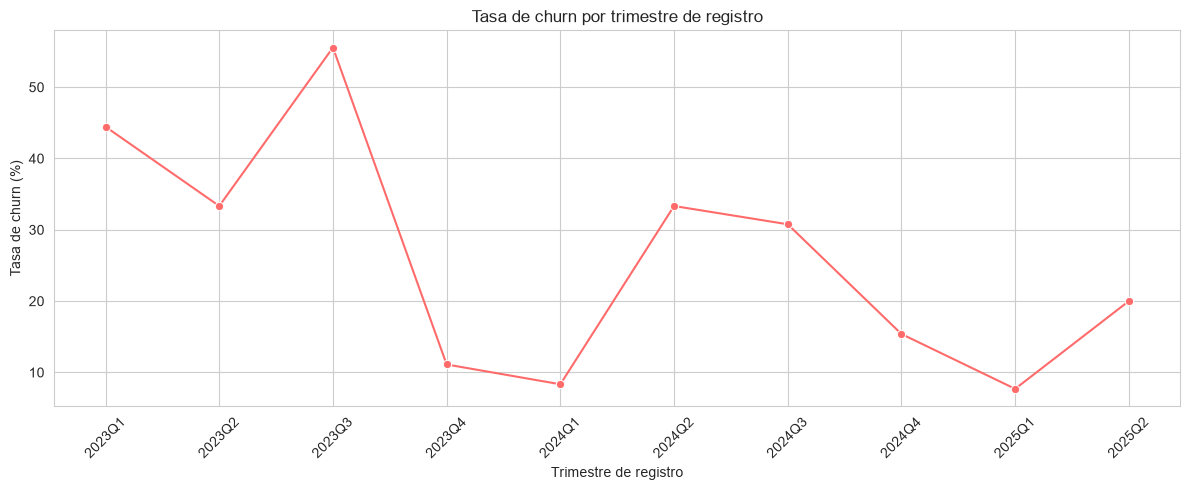

In [34]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=churn_trimestre,x="trimestre_registro",y="tasa_churn",marker="o",color="#FF6B6B")
plt.title("Tasa de churn por trimestre de registro")
plt.xlabel("Trimestre de registro")
plt.ylabel("Tasa de churn (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se puede observar que la tasa de churn mas alta se presento en el tercer Q del año 2023, alcanzando aproximadamente el 55% sin embargo, se puede observar una tendencia a la baja, lo que sugieren una mejora en la retencion de clientes

In [35]:
#Agrupacion por mes de la ultima compra
df["mes_ultima_compra"] = (df["last_purchase_date"].dt.to_period("M").astype(str))
ultima_compra_mes = (df.groupby("mes_ultima_compra").size().reset_index(name="cantidad_clientes"))

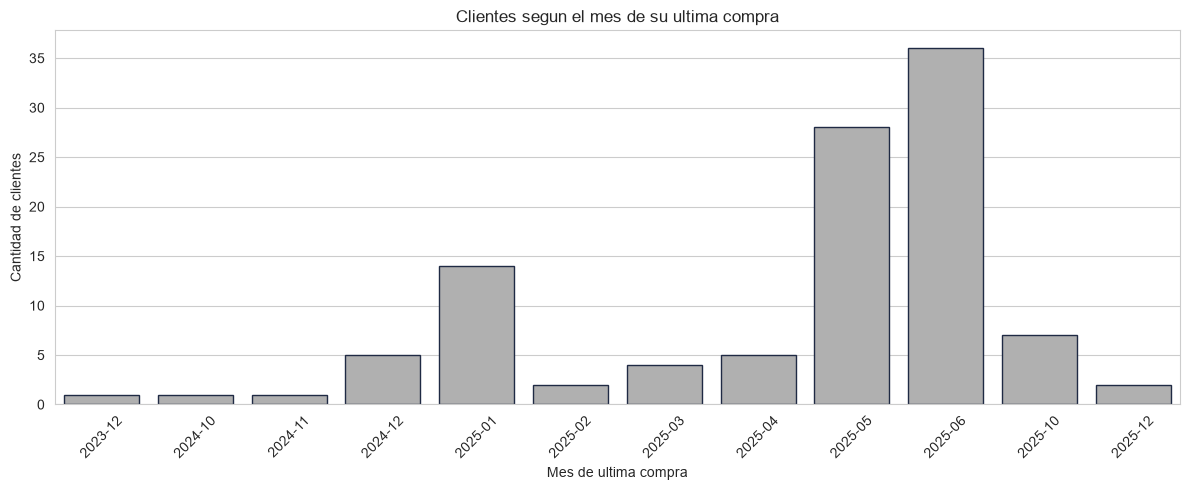

In [36]:
plt.figure(figsize=(12, 5))

sns.barplot(data=ultima_compra_mes,x="mes_ultima_compra", y="cantidad_clientes", color="#B0B0B0", edgecolor="#1F2A44")
plt.title("Clientes segun el mes de su ultima compra")
plt.xlabel("Mes de ultima compra")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Las últimas compras de los clientes se concentran principalmente en mayo y junio de 2025, con 28 y mas de 36 clientes aproximadamente, los meses que no aparecen en la grafica no tienen registros de ultimas compras. Los clientes con fechas mas antiguas podrian presentar mayor inactividad, pero esto debe validarse comparando la fecha de ultima compra con el churn_label

### Variables temporales

Las fechas por si solas no pueden ser utilizadas directamente por la mayoria de algoritmos de Machine Learning, por lo que se transforman en variables numericas que representan el comportamiento temporal de cada cliente.

In [37]:
#Inactivdad de los clientes tomando como fecha de referencia last_purchase_date
fecha_referencia = df["last_purchase_date"].max()
df["dias_desde_ultima_compra"] = (fecha_referencia - df["last_purchase_date"]).dt.days
df.head(5)

,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,customer_id_anonymous,mes_registro,trimestre_registro,mes_ultima_compra,dias_desde_ultima_compra
0,2023-01-15,2025-12-05,450.5,12.0,0.0,C00000,2023-01,2023Q1,2025-12,1.0
1,2023-02-20,2025-05-10,1200.0,45.0,0.0,C00001,2023-02,2023Q1,2025-05,210.0
2,2023-04-12,2025-06-01,890.2,22.0,0.0,C00002,2023-04,2023Q2,2025-06,188.0
3,2023-05-30,2024-12-20,310.0,5.0,1.0,C00003,2023-05,2023Q2,2024-12,351.0
4,2023-06-21,2025-04-15,2500.0,NaN,0.0,C00004,2023-06,2023Q2,2025-04,235.0


In [38]:
df.groupby("churn_label")["dias_desde_ultima_compra"].describe()

,count,mean,std,min,25%,50%,75%,max
churn_label,,,,,,,,
0.0,80.0,187.600000,67.114035,0.0,174.0,188.0,205.00,335.0
1.0,26.0,315.307692,102.663633,179.0,256.0,330.0,348.25,707.0


Los clientes que presentaron churn llevan en promedio 315 dias sin comprar, mientras que los clientes que permanecen activos registran un promedio de 198 dias. Ademas, la mediana es mayor en los clientes con churn: 330 dias frente a 190 dias. Esto indica que un mayor tiempo desde la ultima compra podria estar relacionado con una mayor probabilidad de abandono

In [39]:
#Antiguedad de los clientes tomando como fecha de referencia last_purchase_date
df["antiguedad_dias"] = (fecha_referencia - df["signup_date"]).dt.days

In [40]:
df.groupby("churn_label")["antiguedad_dias"].describe()

,count,mean,std,min,25%,50%,75%,max
churn_label,,,,,,,,
0.0,82.0,561.036585,242.178765,200.0,367.0,536.5,743.25,1056.0
1.0,27.0,681.814815,266.795087,219.0,474.5,701.0,898.50,1070.0


Los clientes que presentaron churn tienen una antiguedad promedio de 682 dias, mientras que los clientes que permanecen activos tienen un promedio de 561 dias. La mediana tambien es mayor en el grupo con churn: 701 dias frente a 536,5 dias. Esto sugiere que los clientes con mayor antiguedad presentan una mayor tendencia al abandono.

### Distribucion de las variables temporales

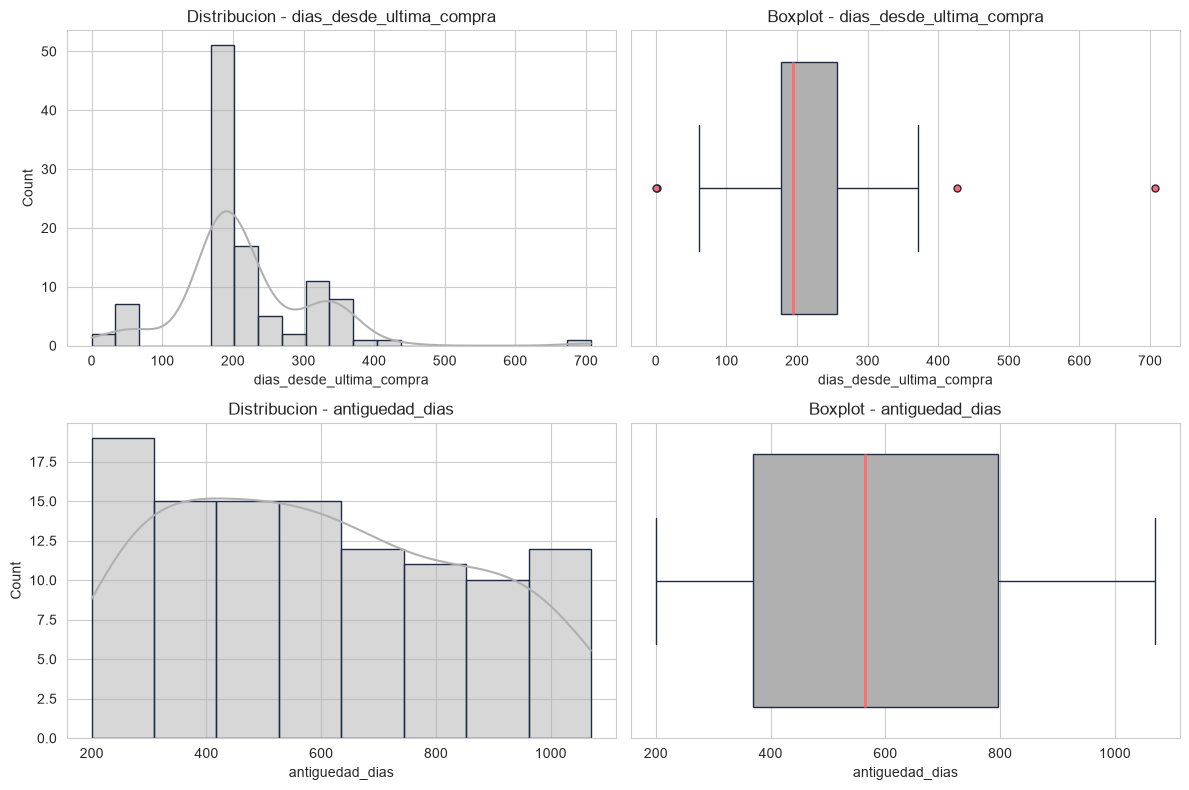

In [41]:
fig, axes = plt.subplots(2,2,figsize=(12, 8))

sns.histplot(df["dias_desde_ultima_compra"].dropna(),kde=True,ax=axes[0, 0],color="#B0B0B0",edgecolor="#1F2A44")
axes[0,0].set_title("Distribucion - dias_desde_ultima_compra")
sns.boxplot(x=df["dias_desde_ultima_compra"].dropna(),ax=axes[0, 1],color= "#B0B0B0", boxprops={"edgecolor": "#1F2A44"},
        whiskerprops={"color": "#1F2A44"},
        capprops={"color": "#1F2A44"},
        medianprops={"color": "#FF6B6B", "linewidth": 2},
        flierprops={
            "marker": "o",
            "markerfacecolor": "#FF6B6B",
            "markeredgecolor": "#1F2A44",
            "markersize": 5
        })
axes[0,1].set_title("Boxplot - dias_desde_ultima_compra")
sns.histplot(df["antiguedad_dias"].dropna(), kde=True, ax=axes[1, 0],color="#B0B0B0",edgecolor="#1F2A44")
axes[1, 0].set_title("Distribucion - antiguedad_dias")
sns.boxplot(x=df["antiguedad_dias"].dropna(), ax=axes[1, 1],color= "#B0B0B0", boxprops={"edgecolor": "#1F2A44"},
        whiskerprops={"color":"#1F2A44"},
        capprops={"color":"#1F2A44"},
        medianprops={"color": "#FF6B6B", "linewidth": 2},
        flierprops={
            "marker":"o",
            "markerfacecolor": "#FF6B6B",
            "markeredgecolor": "#1F2A44",
            "markersize":5
        })
axes[1,1].set_title("Boxplot - antiguedad_dias")
plt.tight_layout()
plt.show()

In [42]:
#Prueba de normalidad
for col in ["dias_desde_ultima_compra", "antiguedad_dias"]:
    stat, p = stats.shapiro(df[col].dropna())
    print(f"{col}: Shapiro-Wilk p-value = {p:.4f} -> "
          f"{'Normal' if p > 0.05 else 'No normal'}")

dias_desde_ultima_compra: Shapiro-Wilk p-value = 0.0000 -> No normal
antiguedad_dias: Shapiro-Wilk p-value = 0.0005 -> No normal


Las variables dias_desde_ultima_compra y antiguedad_dias no presentan una distribucion normal, lo cual se confirma mediante la prueba de Shapiro-Wilk, con valores p inferiores a 0,05. dias_desde_ultima_compra presenta asimetria hacia la derecha y valores atipicos, mientras que antiguedad_dias muestra una alta dispersion, pero sin valores atipicos evidentes. Por esta razon, para describir estas variables es preferible utilizar la mediana

### Analisis de missingness

In [43]:
df.isnull().mean().round(4)*100

signup_date                  0.00
last_purchase_date           2.75
monthly_spend               19.27
total_shipments              1.83
churn_label                  0.00
customer_id_anonymous        0.00
mes_registro                 0.00
trimestre_registro           0.00
mes_ultima_compra            2.75
dias_desde_ultima_compra     2.75
antiguedad_dias              0.00
dtype: float64

In [44]:
#features con nulos
cols_con_nulos = ["monthly_spend", "total_shipments", "dias_desde_ultima_compra"]

for col in cols_con_nulos:
    flag = f"{col}_is_null"
    df[flag] = df[col].isnull().astype(int)
    tasa = df.groupby(flag)["churn_label"].mean().round(4) * 100
    conteo = df.groupby(flag)["churn_label"].size()
    print(f"{col}")
    print(pd.DataFrame({"tasa_churn_%": tasa, "n": conteo}))

monthly_spend
                       tasa_churn_%   n
monthly_spend_is_null                  
0                             20.45  88
1                             42.86  21
total_shipments
                         tasa_churn_%    n
total_shipments_is_null                   
0                               25.23  107
1                                0.00    2
dias_desde_ultima_compra
                                  tasa_churn_%    n
dias_desde_ultima_compra_is_null                   
0                                        24.53  106
1                                        33.33    3


El analisis de missingness muestra que los clientes con valores nulos en monthly_spend presentan una tasa de churn de 42,86 %, frente al 20,45 % de quienes tienen informacion. Esto indica que la ausencia de esta variable podria contener informacion relacionada con el abandono y no deberia eliminarse sin analisis. En total_shipments y dias_desde_ultima_compra hay muy pocos valores nulos, por lo que sus tasas de churn no permiten obtener conclusiones confiables

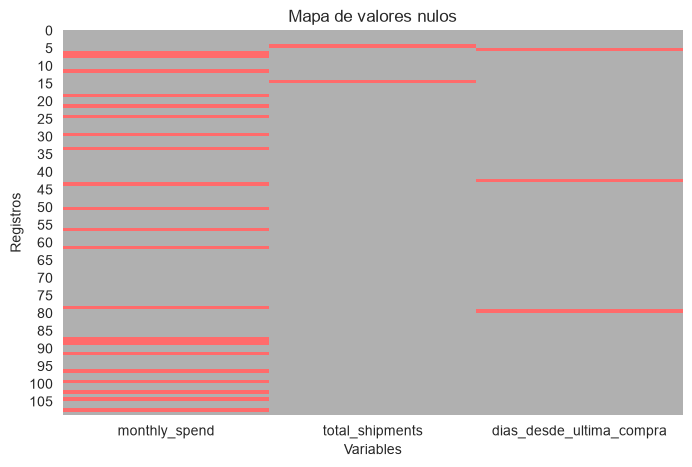

In [45]:
plt.figure(figsize=(8, 5))

sns.heatmap(df[cols_con_nulos].isnull(),cbar=False, cmap=["#B0B0B0", "#FF6B6B"])
plt.title("Mapa de valores nulos")
plt.xlabel("Variables")
plt.ylabel("Registros")
plt.show()

El mapa de valores nulos evidencia que la mayor concentracion de datos faltantes se encuentra en monthly_spend y que no existe un patron de ausencia completamente compartido entre las variables.

In [46]:
#test fisher debido a que ma muestra es pequeña, para validar relacion de valores nulos con churn_label
for col in cols_con_nulos:
    flag = f"{col}_is_null"
    tabla = pd.crosstab(df[flag], df["churn_label"])
    if tabla.shape[0] > 1 and tabla.shape[1] > 1:
        odds_ratio, p = fisher_exact(tabla)
        print(f"{col}: fisher p-value = {p:.4f} -> "
              f"{'Relacion significativa con churn' if p < 0.05 else 'Sin relacion significativa'}")
    else:
        print(f"{col}: no hay suficiente variacion para test (solo una categoria)")

monthly_spend: fisher p-value = 0.0477 -> Relacion significativa con churn
total_shipments: fisher p-value = 1.0000 -> Sin relacion significativa
dias_desde_ultima_compra: fisher p-value = 1.0000 -> Sin relacion significativa


La prueba exacta de Fisher muestra una relacion estadisticamente significativa entre la ausencia de datos en monthly_spend y el churn, con un valor p de 0,0477. Esto sugiere que los valores nulos de esta variable podrian contener informacion relacionada con el abandono. Para total_shipments y dias_desde_ultima_compra, los valores p son mayores a 0,05, por lo que no se encontro evidencia suficiente de una relacion entre sus valores nulos y el churn. conviene conservar un indicador de ausencia

## Analisis bivariado

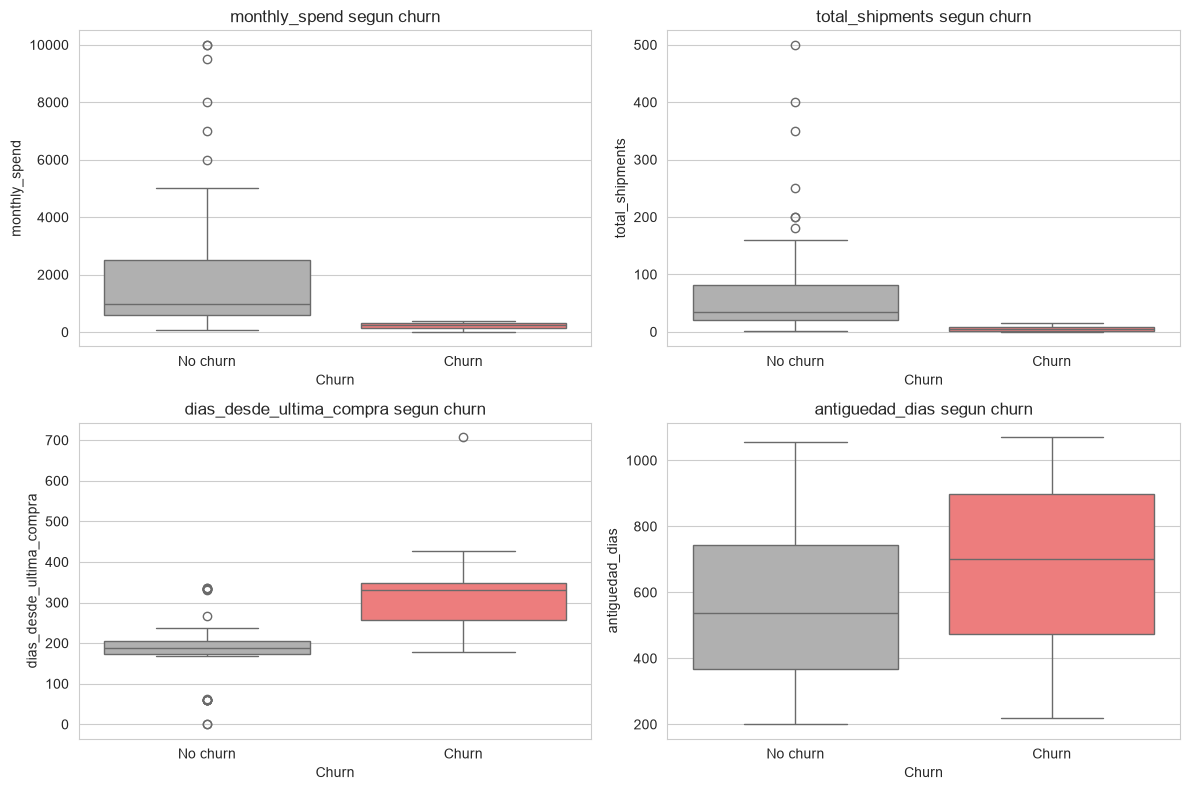

In [47]:
#Comportamiento de features vs target
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(["monthly_spend", "total_shipments", "dias_desde_ultima_compra","antiguedad_dias"]):
    
    sns.boxplot(data=df, x="churn_label",y=col, hue="churn_label",palette={0: "#B0B0B0",1: "#FF6B6B"}, legend=False,ax=axes[i])
    axes[i].set_title(f"{col} segun churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No churn", "Churn"])
plt.tight_layout()
plt.show()

Los clientes con churn presentan menos gastos mensuales y menor cantidad de envios que los clientes que permanecen activos, ademas, registran mas dias desde su ultima compra y una mayor antiguedad. Esto sugiere que la baja actividad comercial y un periodo prolongado sin comprar podrian estar relacionados con el abandono. Sin embargo, estas diferencias deben confirmarse mediante pruebas estadisticas

In [48]:
#prueba no parametrica de Mann-Whitney U
for col in ["monthly_spend", "total_shipments", "dias_desde_ultima_compra","antiguedad_dias"]:
    grupo_0 = df[df["churn_label"] == 0][col].dropna()
    grupo_1 = df[df["churn_label"] == 1][col].dropna()
    if len(grupo_0) > 0 and len(grupo_1) > 0:
        stat, p = mannwhitneyu(grupo_0, grupo_1)
        print(f"{col}: Mann-Whitney U p-value = {p:.4f} -> "
              f"{'Diferencia significativa' if p < 0.05 else 'Sin diferencia significativa'}")

monthly_spend: Mann-Whitney U p-value = 0.0000 -> Diferencia significativa
total_shipments: Mann-Whitney U p-value = 0.0000 -> Diferencia significativa
dias_desde_ultima_compra: Mann-Whitney U p-value = 0.0000 -> Diferencia significativa
antiguedad_dias: Mann-Whitney U p-value = 0.0411 -> Diferencia significativa


La prueba de Mann–Whitney muestra diferencias estadisticamente significativas entre los clientes con churn y sin churn en las cuatro variables analizadas, ya que todos los valores p son menores a 0,05
Se puede inferir que los clientes con churn tienden a tener menor gasto, menos envios, mayor tiempo desde su ultima compra y mayor antiguedad, por lo que estas variables podrian ser relevantes para predecir el abandono

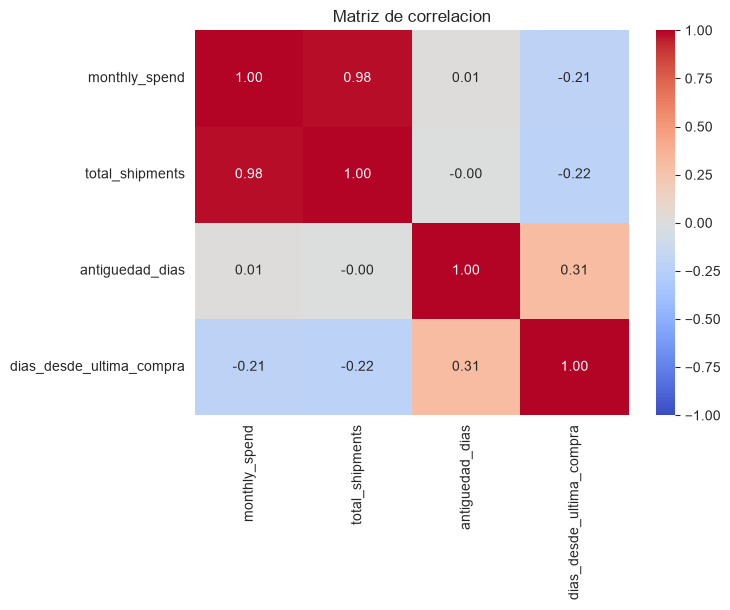

In [49]:
#Matriz de correlaciones
corr = df[["monthly_spend", "total_shipments", "antiguedad_dias", "dias_desde_ultima_compra"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de correlacion")
plt.show()

La matriz de correlacion evidencia una relacion positiva muy alta entre monthly_spend y total_shipments, lo que indica que los clientes con mayor cantidad de envios tienden a presentar un mayor gasto mensual, sin embargo, tambien sugiere una posible multicolinealidad, dado que ambas variables podrian aportar informacion redundante al modelo. Por otro lado, las variables temporales presentan correlaciones debiles con el gasto y la cantidad de envios. En particular, dias_desde_ultima_compra muestra una relacion negativa debil con monthly_spend y total_shipments, lo que sugiere que una mayor inactividad esta asociada con menores niveles de gasto y actividad.

In [50]:
#Validar multicolinialidad
variables = [
    "monthly_spend",
    "total_shipments",
    "antiguedad_dias",
    "dias_desde_ultima_compra"
]

X_vif = df[["monthly_spend","total_shipments","antiguedad_dias","dias_desde_ultima_compra"]].dropna()
X_vif = add_constant(X_vif)
vif = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])]
})

vif

,variable,VIF
0,const,10.609616
1,monthly_spend,23.108837
2,total_shipments,23.113762
3,antiguedad_dias,1.098604
4,dias_desde_ultima_compra,1.144049


La evaluacion de la multicolinealidad mediante el Factor de Inflación de la Varianza (VIF) evidencio valores elevados para las variables monthly_spend y total_shipments, indicando una multicolinealidad severa entre ambas. Este resultado es consistente con la matriz de correlacion, donde se observo una correlacion positiva de 0.98. En contraste, antiguedad_dias y dias_desde_ultima_compra presentaron valores de VIF inferiores a 5, por lo que no representan un problema de multicolinealidad.

En este caso debido a los resultados anteriores es conveniente utilizar modelos como XGBoost, no se eliminaran inicialmente las variables con alta multicolinealidad, ya que este tipo de algoritmo basado en arboles no suele verse afectado significativamente por este fenomeno. No obstante, posteriormente se evaluara la importancia de las variables y se comparara el desempeño del modelo con y sin estas variables para determinar si existe informacion redundante que pueda simplificarse sin afectar la capacidad predictiva.

La imputacion de los valores faltantes se aplicara despues de seperar entrenamiento y prueba, dentro de el pipeline, utilizando SMOTE como metodo de imputacion unicamente en los datos de entrenamiento para evitar data leakage